## Redes Neurais Artificiais 2025.2

- **Disciplina**: Redes Neurais Artificiais 2025.2
- **Professora**: Elloá B. Guedes (ebgcosta@uea.edu.br)  
- **Github**: http://github.com/elloa  

# Importação das Bibliotecas

In [32]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import ast
from prettytable import PrettyTable
import warnings

from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import confusion_matrix

# Carregamento das Informações

In [6]:
# Carregamento dos csvs e dos modelos
path_sgd_csv = 'Resultados/Alexandro/cv_results.csv'
path_adam_csv = 'Resultados/Eduardo/cv_results.csv'

df_sgd = pd.read_csv(path_sgd_csv)
df_adam = pd.read_csv(path_adam_csv)

df_all = pd.concat([df_sgd, df_adam], ignore_index=True)
top_5 = df_all.sort_values(by='mean_test_score', ascending=False).head(5).copy()

melhor_sgd = 'Resultados/Alexandro/10-Melhores/modelo_top1.joblib'
melhor_adam = 'Resultados/Eduardo/10-Melhores/modelo_top1.joblib'

modelo_sgd = joblib.load(melhor_sgd)
modelo_adam = joblib.load(melhor_adam)
melhores_modelos = [('Melhor SGD', modelo_sgd), ('Melhor Adam', modelo_adam)]

In [8]:
# Carregamento do dataset
df = pd.read_csv('Dataset/dataset_tratado.csv')
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

X_full = pd.get_dummies(X)
class_names = sorted(y.unique())

In [9]:
# Agrupar as arquiteturas em dois grandes grupos
def contar_camadas(s):
    try:
        t = ast.literal_eval(str(s)) 
        if isinstance(t, int): return 1
        return len(t)
    except:
        return 1

# Cria coluna nova: "1 Camada" ou "2 Camadas"
df_all['n_camadas'] = df_all['param_hidden_layer_sizes'].apply(contar_camadas).astype(str) + " Camada(s)"
top_5['n_camadas'] = top_5['param_hidden_layer_sizes'].apply(contar_camadas).astype(str) + " Camada(s)"

# 7. Análise de Desempenho dos Modelos

## Distribuição de Desempenho por Otimizador

In [10]:
def plot_performance_distribution(df, solver_name, color):
    plt.figure(figsize=(9, 6))
    subset = df[df['param_solver'] == solver_name]
    
    sns.histplot(subset['mean_test_score'], bins=20, kde=True, color=color)
    plt.title(f'Distribuição de Desempenho - {solver_name}')
    plt.xlabel('F1-Macro')
    plt.ylabel('Frequência de Modelos')
    plt.show()

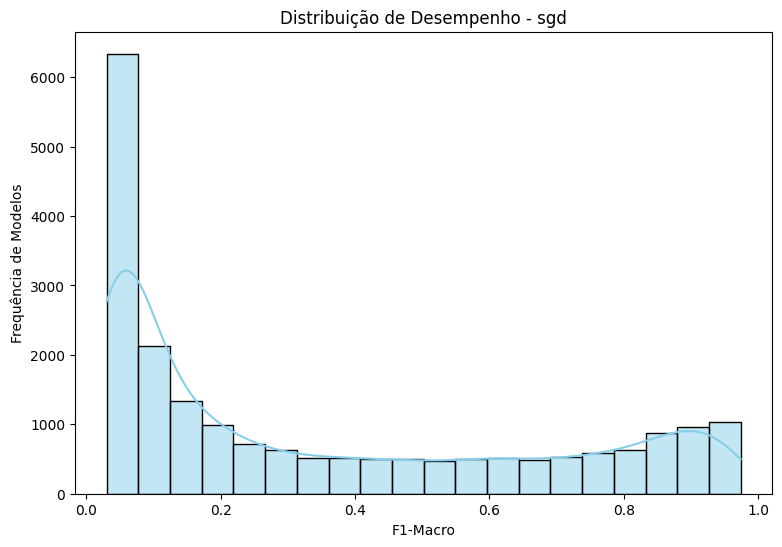

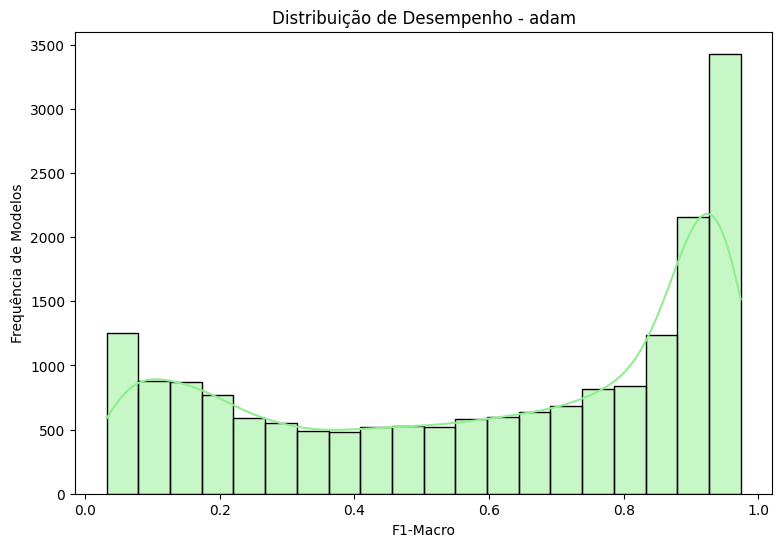

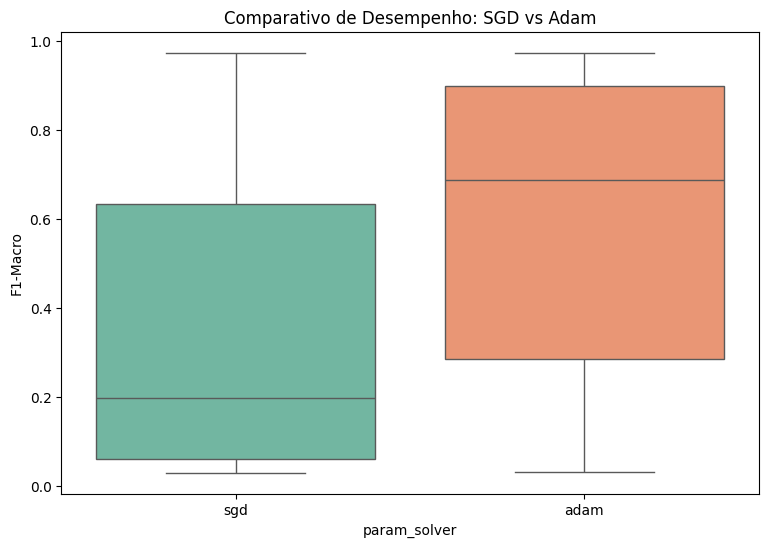

In [11]:
plot_performance_distribution(df_all, 'sgd', 'skyblue')
plot_performance_distribution(df_all, 'adam', 'lightgreen')

plt.figure(figsize=(9, 6))
sns.boxplot(x='param_solver', y='mean_test_score', hue='param_solver', legend=False, data=df_all, palette="Set2")
plt.title('Comparativo de Desempenho: SGD vs Adam')
plt.ylabel('F1-Macro')
plt.show()

Ao comparar a distribuição de desempenho dos otimizadores, é possível perceber uma distinção de como cada treino ocorreu:
- SGD: Seu histograma apresenta uma distribuição fortemente enviesada para a esquerda, e o seu gráfico boxplot mostra que aproximadamente 50% dos modelos apresentou um F1-Macro igual ou inferior a 0.2. Neste caso, o modelo estava escolhendo aleatoriamente as classes a serem previstas, visto que 1/7 ≈ 14%, indicando que o otimizador frequentemente falhou em convergir, ficando preso em mínimos locais ou não superando a aleatoriedade inicial.
- Adam: Seu histograma apresenta uma distribuição concentrada em valores mais altos, demonstrando uma capacidade superior de generalização. Ao contrário do SGD, a mediana dos modelos Adam situa-se próxima a 0.69, com os 25% melhores modelos alcançando F1-Macros superiores a 0.90. Isso sugere que o Adam, graças às suas taxas de aprendizado adaptativas, conseguiu navegar pela superfície de erro de forma muito mais eficiente, convergindo para soluções ótimas na grande maioria das configurações de hiperparâmetros testadas, mostrando-se uma escolha muito mais robusta e segura para este problema.

## Distribuição de Desempenho por Hiperparâmetros

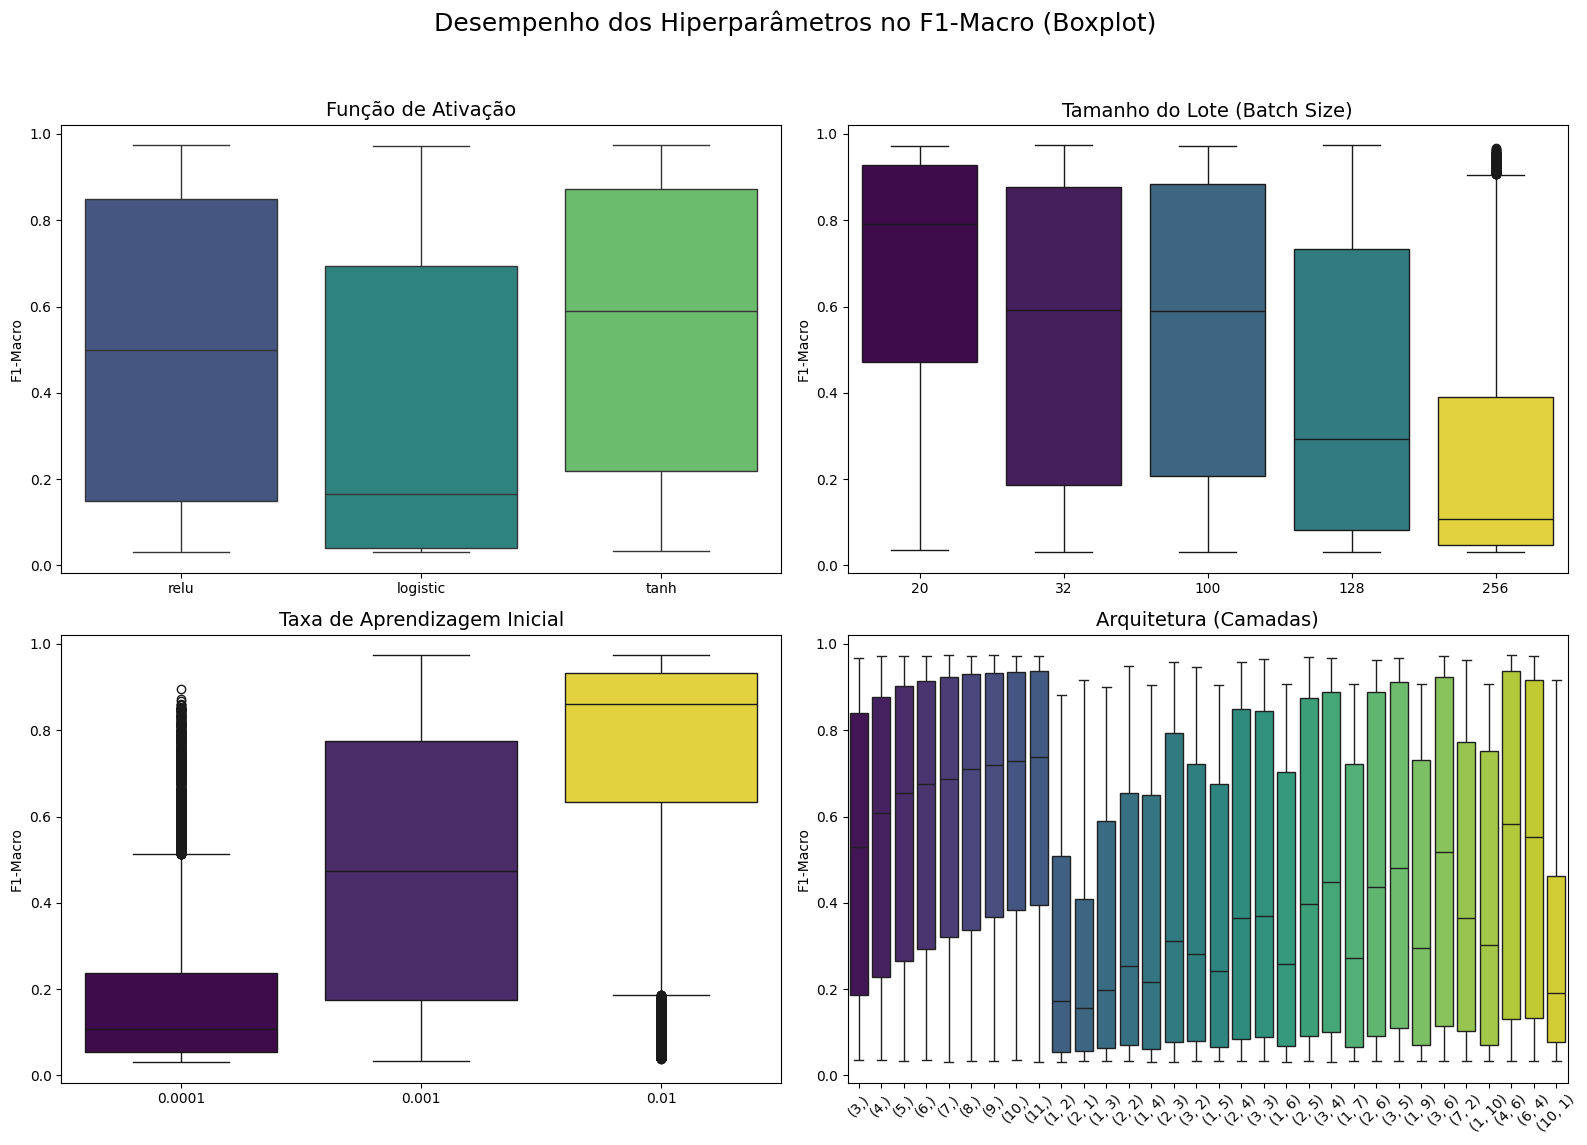

In [12]:
params_cols = ['param_activation', 'param_batch_size', 'param_learning_rate_init', 'param_hidden_layer_sizes']
titulos = ['Função de Ativação', 'Tamanho do Lote (Batch Size)', 'Taxa de Aprendizagem Inicial', 'Arquitetura (Camadas)']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Desempenho dos Hiperparâmetros no F1-Macro (Boxplot)', fontsize=18)

for ax, col, titulo in zip(axes.flatten(), params_cols, titulos):
    sns.boxplot(x=col, y='mean_test_score', hue=col, legend=False, data=df_all, palette="viridis", ax=ax)
            
    ax.set_title(titulo, fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('F1-Macro')
        
    if col == 'param_hidden_layer_sizes':
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Ao realizar a comparação de desempenho quanto aos demais parâmetros dos modelos, é notório a presença de alguns padrões, sendo eles:
1. Equilíbrio entre as funções de ativação Relu e Tanh.

Ambas as funções Relu e Tanh obtiveram resultados semelhantes neste treinamento, se mostrando as melhores opções para esta tarefa, enquanto a Logistic obteve resultados piores, provavelmente por ser mais aconselhada para problemas binários.

2. Favorecimento a tamanhos de lotes menores.

Esse fato indica que as atualizações mais frequentes durante o treinamento e a maior capacidade de escapar de mínimos locais são favoráveis para este dataset.

3. Eficiência de taxas de aprendizagem iniciais menores.

A taxa de aprendizagem inicial 0.01 apresentou uma média maior e mais estabilidade, provando que uma convergência rápida é mais eficiente para o treinamento.

4. Preferência a arquiteturas de uma camada sobre arquiteturas de duas camadas.

Mostra que treinar modelos com poucas camadas já é suficiente para este dataset, e que possivelmente mais camadas podem influenciar negativamente no treinamento.

## Melhores Modelos (Otimizador)

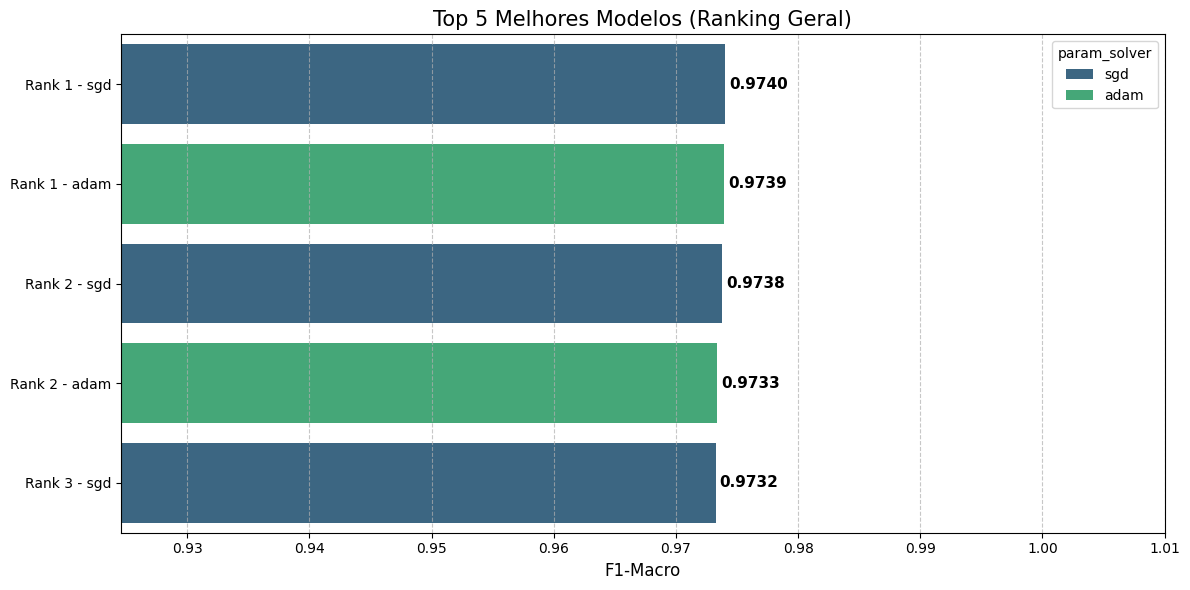

In [13]:
top_5['Label'] = (
    "Rank " + top_5['rank_test_score'].astype(str) + 
    " - " + top_5['param_solver']
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x='mean_test_score', 
    y='Label', 
    data=top_5, 
    hue='param_solver', 
    dodge=False, 
    palette='viridis'
)

plt.title('Top 5 Melhores Modelos (Ranking Geral)', fontsize=15)
plt.xlabel('F1-Macro', fontsize=12)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=11, fontweight='bold')

min_score = top_5['mean_test_score'].min()
plt.xlim(min_score * 0.95, 1.01)

plt.tight_layout()
plt.show()

Indo de forma não intuitiva aos resultados mostrados anteriormente, percebe-se que a presença no topo do ranking entre os otimizadores está equilibrada, demonstrando que, um otimizador mais robusto (Ou seja, que obtem melhores resultados de forma distribuida entre todos os seus modelos) não é necessariamente o  otimizador com melhor desempenho de pico (Ou seja, aquele que obtem os melhores resultados absolutos em todo o treinamento), o que se concretiza pelo fato do otimizador SGD estar presente no melhor modelo.

## Melhores Modelos (Outros parâmetros)

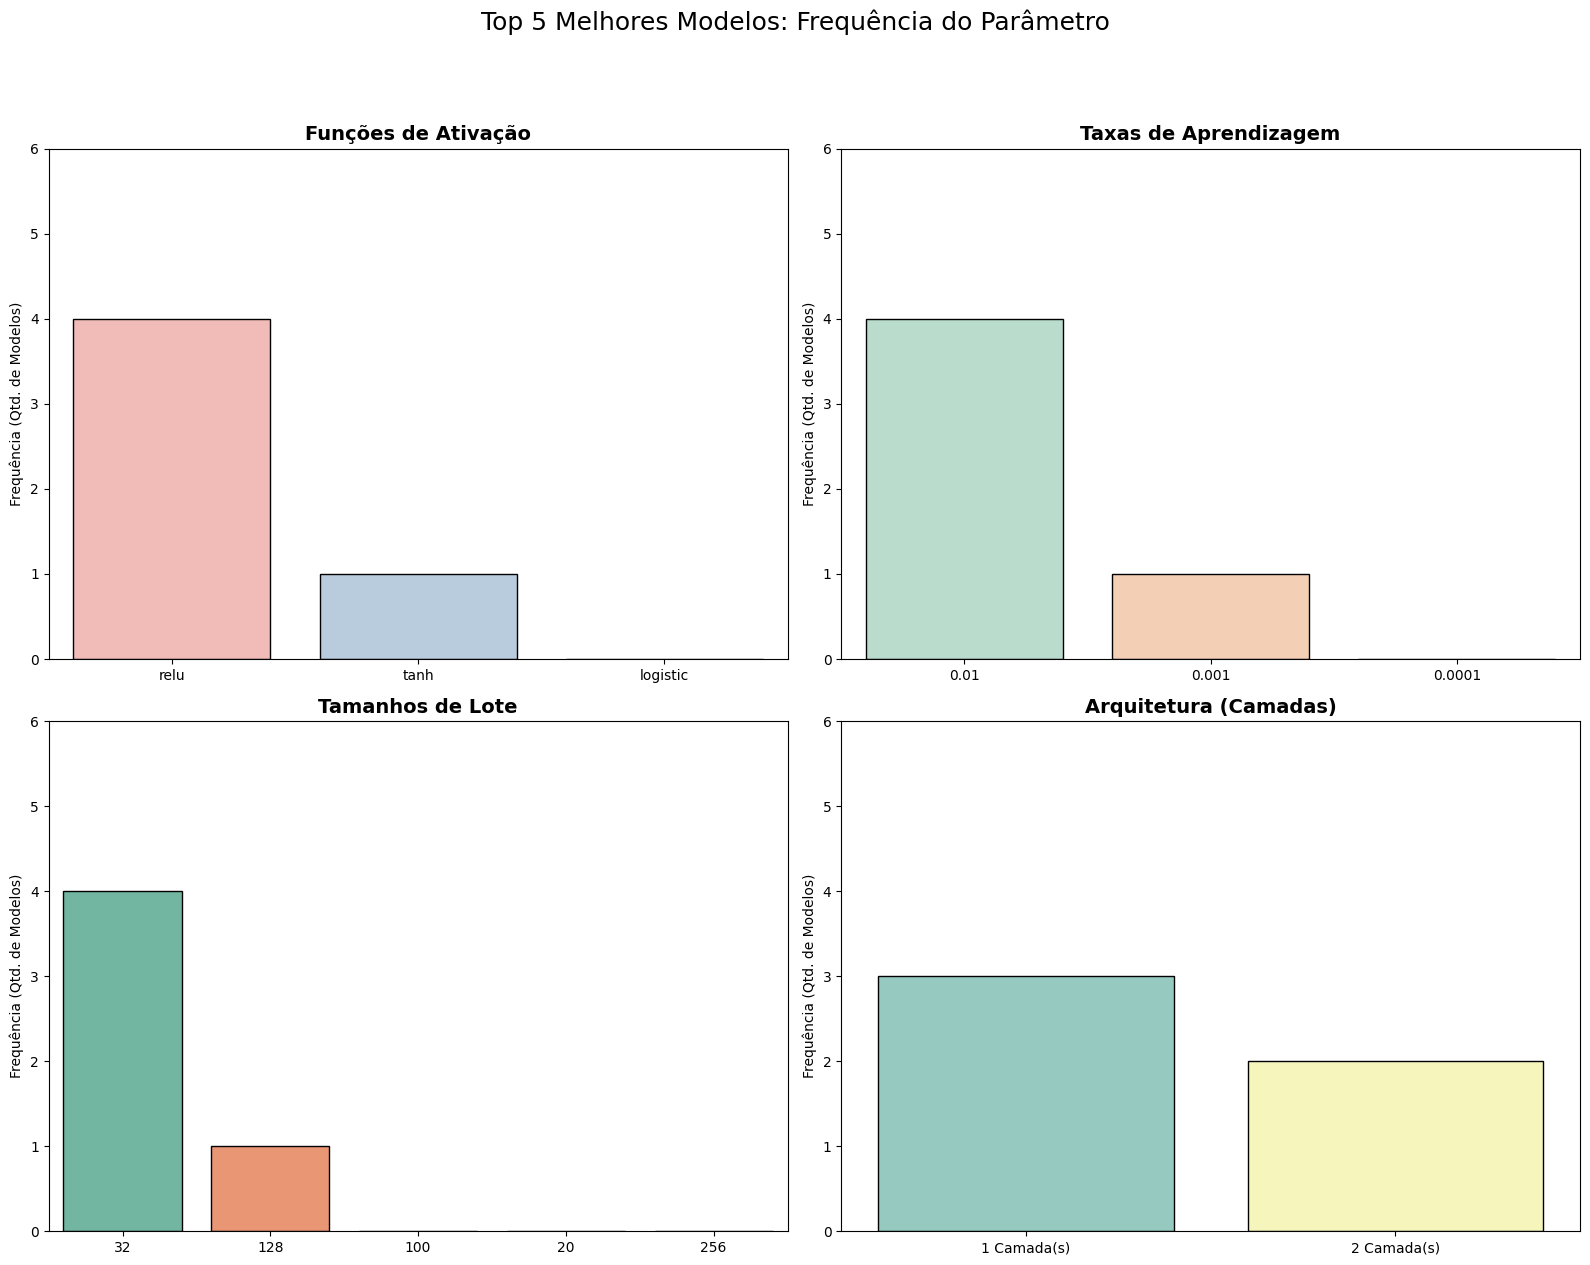

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top 5 Melhores Modelos: Frequência do Parâmetro', fontsize=18, y=1.05)

params = [
    ('param_activation', 'Funções de Ativação', 'Pastel1'),
    ('param_learning_rate_init', 'Taxas de Aprendizagem', 'Pastel2'),
    ('param_batch_size', 'Tamanhos de Lote', 'Set2'),
    ('n_camadas', 'Arquitetura (Camadas)', 'Set3')
]

for ax, (col, titulo, paleta) in zip(axes.flatten(), params):
        
    todos_valores = df_all[col].astype(str).unique()
    
    resumo = top_5.groupby(col)['mean_test_score'].agg(['count', 'mean']).reset_index()
    resumo[col] = resumo[col].astype(str)
        
    df_completo = pd.DataFrame({col: todos_valores})
    resumo_final = pd.merge(df_completo, resumo, on=col, how='left')
        
    resumo_final['count'] = resumo_final['count'].fillna(0)
    resumo_final = resumo_final.sort_values(by=['count', col], ascending=[False, True])
        
    sns.barplot(
        x=col, 
        y='count',
        hue=col,
        legend=False,
        data=resumo_final, 
        palette=paleta, 
        ax=ax,
        edgecolor='black'
    )
        
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frequência (Qtd. de Modelos)')
        

    ax.set_ylim(0, top_5.shape[0] + 1.0)
        
    ax.yaxis.get_major_locator().set_params(integer=True)

plt.tight_layout()
plt.show()

Isolando os 5 modelos com melhor desempenho e analisar a frequência de seus hiperparâmetros, identificamos um padrão de convergência claro. O gráfico revela que, apesar das diferenças entre os otimizadores (Adam vs SGD), existe uma combinação superior que favorece a maximização do F1-Macro neste dataset:

1. Predomínio da Ativação ReLU Observa-se uma preferência quase absoluta pela função de ativação ReLU entre os melhores modelos.

Isso indica que a não-linearidade do problema é melhor tratada por funções que evitam o problema do desvanecimento de gradiente (comum na Sigmoide/Tanh em redes mais profundas) e que proporcionam um aprendizado mais esparso e eficiente computacionalmente.

2. Eficiência de Lotes Pequenos (Batch Size 32) O parâmetro Batch Size de 32 é dominante.

Lotes menores introduzem um ruído estocástico benéfico durante a atualização dos pesos, ruído este que ajudou o modelo a escapar de mínimos locais precoces (onde modelos com lotes grandes, como 128 ou 200, tendem a ficar presos) e favoreceu uma melhor generalização para os dados de teste.

3. Taxa de Aprendizagem Agressiva (0.01) A maioria dos modelos de elite utilizou uma taxa inicial de 0.01, superando taxas mais conservadoras (como 0.001).

Isso sugere que a superfície de erro do problema permite passos maiores em direção ao mínimo global sem causar divergência. Combinado com o uso de solvers adaptativos ou com momentum, essa taxa permitiu uma convergência mais rápida e eficaz.

4. Arquitetura (Camadas Ocultas) Nota-se um equilíbrio entre arquiteturas de 1 e 2 camadas.

Isso demonstra que há um equilíbrio entre arquiteturas de 1 e 2 camadas, sem haver um vencedor claro. Além disso, como foi possível obter modelos com desempenho extremamente favorável com poucas camadas, sugere-se que é desnecessário a criação de modelos com números de camadas maiores para este dataset.

Conclusão:
A análise sugere que o sucesso na classificação da obesidade neste cenário não dependeu de força bruta (redes gigantes ou treinamento lento), mas sim de dinamismo. A combinação vencedora (ReLU + Batch 32 + LR 0.01) caracteriza modelos ágeis, que aprendem rápido e generalizam bem graças à estocasticidade dos lotes pequenos.

## Verificação de Overfitting

In [17]:
def evaluate_model_kfold(path, X, y, name, k=5):
    loaded_model = joblib.load(path)
        
    model_to_validate = clone(loaded_model)
        
    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision_macro',
        'recall': 'recall_macro',
        'f1': 'f1_macro'
    }
        
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
        
    scores = cross_validate(model_to_validate, X, y, cv=cv, scoring=scoring, return_train_score=True)
        
    mean_acc = np.mean(scores['test_accuracy'])
    mean_prec = np.mean(scores['test_precision'])
    mean_rec = np.mean(scores['test_recall'])
    mean_f1_test = np.mean(scores['test_f1'])
    mean_f1_train = np.mean(scores['train_f1'])
        
    diff = mean_f1_train - mean_f1_test
        
    if diff > 0.05:
        status = "Overfitting"
    elif diff < -0.05:
        status = "Underfitting"
    else:
        status = "Ok"
            
    return [
        name, 
        round(mean_acc, 4), 
        round(mean_prec, 4), 
        round(mean_rec, 4), 
        round(mean_f1_test, 4), 
        round(mean_f1_train, 4), 
        status
    ]

In [28]:
model_paths = [
    ('Top 1 (SGD)', 'Resultados/Alexandro/10-Melhores/modelo_top1.joblib'),
    ('Top 2 (Adam)', 'Resultados/Eduardo/10-Melhores/modelo_top1.joblib'), 
    ('Top 3 (SGD)', 'Resultados/Alexandro/10-Melhores/modelo_top2.joblib'),
    ('Top 4 (Adam)', 'Resultados/Eduardo/10-Melhores/modelo_top2.joblib'),
    ('Top 5 (SGD)', 'Resultados/Alexandro/10-Melhores/modelo_top3.joblib')
]

tabela = PrettyTable()
tabela.field_names = ["Modelo", "Acurácia (Média)", "Precision", "Recall", "F1-Macro (Teste)", "F1-Macro (Treino)", "Status"]

print(f"\n--- Avaliando Robustez dos Top Modelos (K-Fold = 5) ---")

warnings.filterwarnings("ignore", category=ConvergenceWarning)

for name, path in model_paths:
    if len(X) > 0:
        row = evaluate_model_kfold(path, X, y, name, k=5)
        if row:
            tabela.add_row(row)

print(tabela)


--- Avaliando Robustez dos Top Modelos (K-Fold = 5) ---
+--------------+------------------+-----------+--------+------------------+-------------------+--------+
|    Modelo    | Acurácia (Média) | Precision | Recall | F1-Macro (Teste) | F1-Macro (Treino) | Status |
+--------------+------------------+-----------+--------+------------------+-------------------+--------+
| Top 1 (SGD)  |      0.9687      |   0.9682  | 0.9679 |      0.9677      |       0.9947      |   Ok   |
| Top 2 (Adam) |      0.9683      |   0.9679  | 0.9678 |      0.9676      |       0.9885      |   Ok   |
| Top 3 (SGD)  |      0.9683      |   0.9682  | 0.9676 |      0.9676      |       0.9949      |   Ok   |
| Top 4 (Adam) |      0.9664      |   0.9658  | 0.9655 |      0.9653      |       0.999       |   Ok   |
| Top 5 (SGD)  |      0.9673      |   0.9668  | 0.9665 |      0.9664      |       0.9831      |   Ok   |
+--------------+------------------+-----------+--------+------------------+-------------------+--------

Ao realizar a verificação para saber se há overfitting, é possível detectar alguns detalhes interessantes:
- A maioria dos modelos apresentou uma queda de 0.02 a 0.03 no F1-Macro na divisão de teste quando comparada com a divisão de treino, indicando que há indícios de um sutil overfitting;
- Além disso, os modelos apresentam um equilíbrio nas métricas de Acurácia, Precisão, Revocação e F1-Macro, indicando que o modelo não escolhe repetidamente uma única classe majoritária.

## Matriz de Confusão

In [29]:
def plot_confusion_matrix_kfold(model, X, y, classes, title, k=5):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    y_true_all = []
    y_pred_all = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model_k = clone(model)
        model_k.fit(X_train, y_train)

        y_pred = model_k.predict(X_test)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

    cm = confusion_matrix(y_true_all, y_pred_all)

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=classes,
                yticklabels=classes)
    plt.title(f'Matriz de Confusão - K-Fold (k={k}) - {title}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

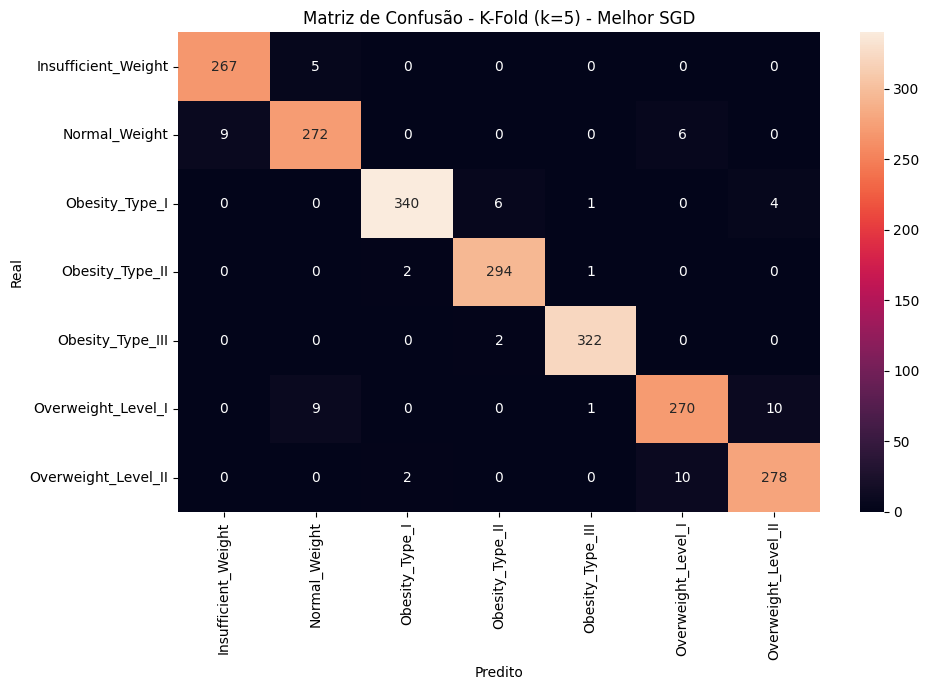

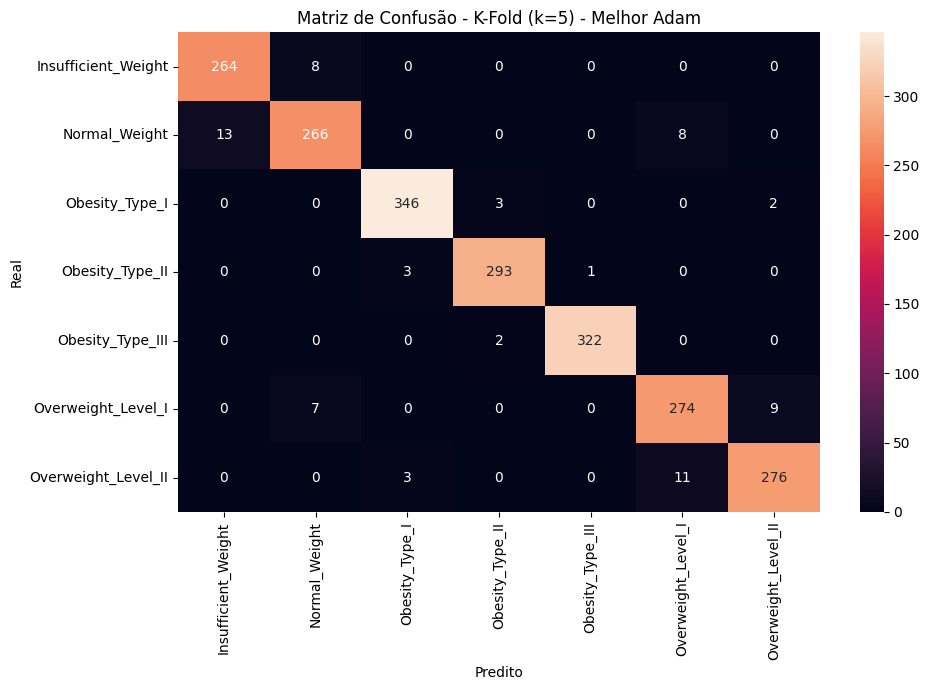

In [33]:
for name, model in melhores_modelos:
    plot_confusion_matrix_kfold(model, X.values, y.values, class_names, name)

A partir dessas matrizes, é possível notar que ambas as diagonais principais estão bem populadas, indicando que ambos os modelos conseguem prever a classe alvo corretamente. Além disso, quanto aos erros, percebe-se que quase todos os erros ocorrem entre classes vizinhas/adjacentes, mostrando que os modelos puderam entender bem a natureza ordinal/sequencial dos dados.